# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Intifada Afkar Lazain Muhammad | 5054251029|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

df = pd.read_csv("mushrooms.csv")
df.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print(df.shape)
df.info()
df.isna().sum()
for x in(df.columns):
    print(x)
    print(df[x].unique())

(8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-a

In [4]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
df.nunique()

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

<Axes: xlabel='class', ylabel='count'>

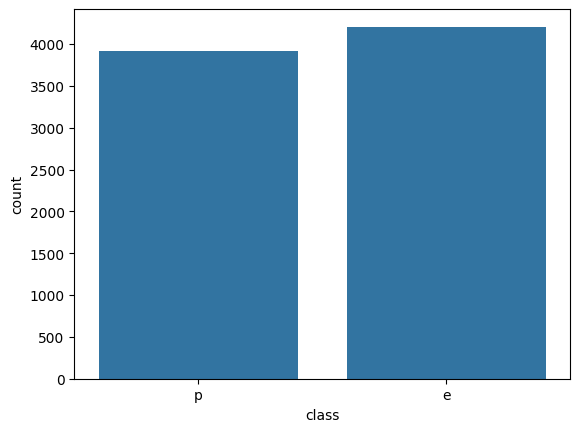

In [5]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
sns.countplot(data=df, x= "class")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

2480
30.53%


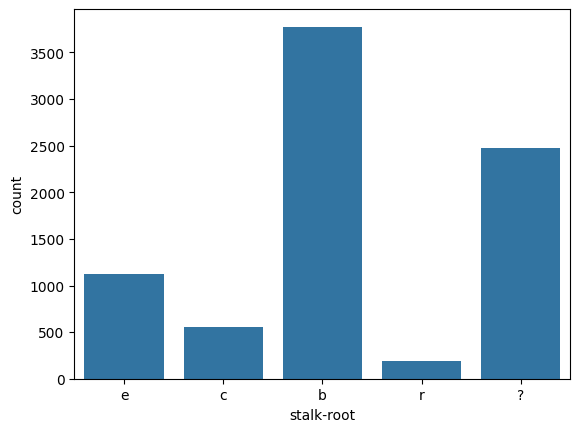

In [6]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
print((df["stalk-root"]=="?").sum())
print(f"{((df['stalk-root'] == '?').sum() / len(df)) * 100:.2f}%")
sns.countplot(x="stalk-root", data=df)
df["stalk-root"] = df["stalk-root"].replace("?", "unknown")


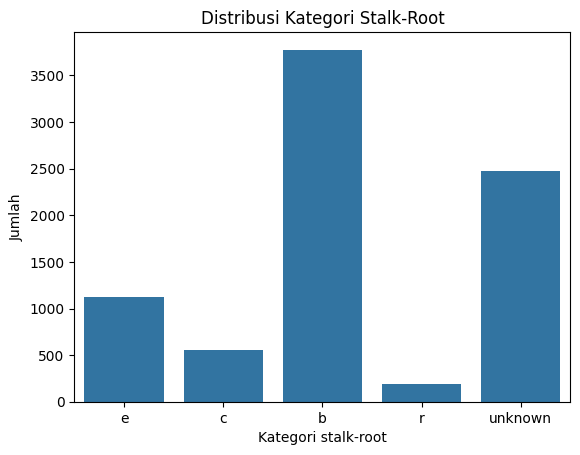

In [7]:
sns.countplot(x="stalk-root", data=df)
plt.title("Distribusi Kategori Stalk-Root")
plt.xlabel("Kategori stalk-root")
plt.ylabel("Jumlah")
plt.show()

In [8]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
print(df.columns[df.nunique() == 1])
df.drop(columns='veil-type',inplace=True)

Index(['veil-type'], dtype='object')


In [9]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

from sklearn.model_selection import train_test_split

X = df.drop(columns="class")
y = df["class"].map({"e": 0, "p": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribusi kelas keseluruhan:")
print(y.value_counts().sort_index())
print("\nDistribusi kelas train:")
print(y_train.value_counts().sort_index())
print("\nDistribusi kelas test:")
print(y_test.value_counts().sort_index())

Distribusi kelas keseluruhan:
class
0    4208
1    3916
Name: count, dtype: int64

Distribusi kelas train:
class
0    3366
1    3133
Name: count, dtype: int64

Distribusi kelas test:
class
0    842
1    783
Name: count, dtype: int64


In [10]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
ordinal_encoder = sk.preprocessing.OrdinalEncoder(dtype=np.int64)

X_train_encoded = ordinal_encoder.fit_transform(X_train)
X_test_encoded = ordinal_encoder.transform(X_test)

print(f"Ukuran X_train_encoded: {X_train_encoded.shape}")
print(f"Ukuran X_test_encoded: {X_test_encoded.shape}")
print(f"Tipe data: {X_train_encoded.dtype}")
print(X_train_encoded[:5])

Ukuran X_train_encoded: (6499, 21)
Ukuran X_test_encoded: (1625, 21)
Tipe data: int64
[[ 2  3  9  0  2  1  0  0  2  0  0  1  1  6  0  2  1  2  1  5  1]
 [ 5  2  5  1  5  1  0  0  1  0  4  2  2  2  7  2  2  0  7  1  6]
 [ 0  2  3  0  5  1  1  0 10  0  4  1  2  7  7  2  2  4  7  3  1]
 [ 2  2  4  0  7  1  0  1  0  1  4  1  1  6  7  2  1  0  7  4  0]
 [ 3  3  4  0  2  1  0  1  0  1  4  2  1  6  6  2  1  0  7  4  4]]


In [21]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
OneHotEncoder_encoder = sk.preprocessing.OneHotEncoder(dtype=np.int64)

X_train_OHEencoded = OneHotEncoder_encoder.fit_transform(X_train)
X_test_OHEencoded = OneHotEncoder_encoder.transform(X_test)

print(f"Ukuran X_train_encoded: {X_train_OHEencoded.shape}")
print(f"Ukuran X_test_encoded: {X_test_OHEencoded.shape}")
print(f"Tipe data: {X_train_OHEencoded.dtype}")
print(X_train_OHEencoded[:5])

Ukuran X_train_encoded: (6499, 116)
Ukuran X_test_encoded: (1625, 116)
Tipe data: int64
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 105 stored elements and shape (5, 116)>
  Coords	Values
  (0, 2)	1
  (0, 9)	1
  (0, 19)	1
  (0, 20)	1
  (0, 24)	1
  (0, 32)	1
  (0, 33)	1
  (0, 35)	1
  (0, 39)	1
  (0, 49)	1
  (0, 51)	1
  (0, 57)	1
  (0, 61)	1
  (0, 70)	1
  (0, 73)	1
  (0, 84)	1
  (0, 87)	1
  (0, 91)	1
  (0, 95)	1
  (0, 108)	1
  (0, 110)	1
  (1, 5)	1
  (1, 8)	1
  (1, 15)	1
  (1, 21)	1
  :	:
  (3, 89)	1
  (3, 101)	1
  (3, 107)	1
  (3, 109)	1
  (4, 3)	1
  (4, 9)	1
  (4, 14)	1
  (4, 20)	1
  (4, 24)	1
  (4, 32)	1
  (4, 33)	1
  (4, 36)	1
  (4, 37)	1
  (4, 50)	1
  (4, 55)	1
  (4, 58)	1
  (4, 61)	1
  (4, 70)	1
  (4, 79)	1
  (4, 84)	1
  (4, 87)	1
  (4, 89)	1
  (4, 101)	1
  (4, 107)	1
  (4, 113)	1


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [25]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
from sklearn.naive_bayes import CategoricalNB
Naive_Bayes = CategoricalNB()
Naive_Bayes.fit(X_train_encoded,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [28]:
# Lakukan prediksi pada test set hasil OrdinalEncoder.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_NB = Naive_Bayes.predict(X_test_encoded)

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [29]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
from sklearn.naive_bayes import BernoulliNB
BNaive_Bayes = BernoulliNB()
BNaive_Bayes.fit(X_train_OHEencoded,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [30]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_BNB = BNaive_Bayes.predict(X_test_OHEencoded)

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [31]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
from sklearn.naive_bayes import MultinomialNB
MNaive_Bayes = MultinomialNB()
MNaive_Bayes.fit(X_train_OHEencoded,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [33]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_MNB = MNaive_Bayes.predict(X_test_OHEencoded)

# 4. Evaluasi Model

In [34]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

hasil_evaluasi = pd.DataFrame({
    "Model": ["Categorical NB", "Bernoulli NB", "Multinomial NB"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_NB),
        accuracy_score(y_test, y_pred_BNB),
        accuracy_score(y_test, y_pred_MNB)
    ],
    "Precision": [
        precision_score(y_test, y_pred_NB, zero_division=0),
        precision_score(y_test, y_pred_BNB, zero_division=0),
        precision_score(y_test, y_pred_MNB, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_NB, zero_division=0),
        recall_score(y_test, y_pred_BNB, zero_division=0),
        recall_score(y_test, y_pred_MNB, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_NB, zero_division=0),
        f1_score(y_test, y_pred_BNB, zero_division=0),
        f1_score(y_test, y_pred_MNB, zero_division=0)
    ]
})

hasil_evaluasi.set_index("Model").round(4)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Categorical NB,0.9458,0.9901,0.8966,0.9410
Bernoulli NB,0.9329,0.9814,0.8774,0.9265
Multinomial NB,0.9458,0.9901,0.8966,0.9410


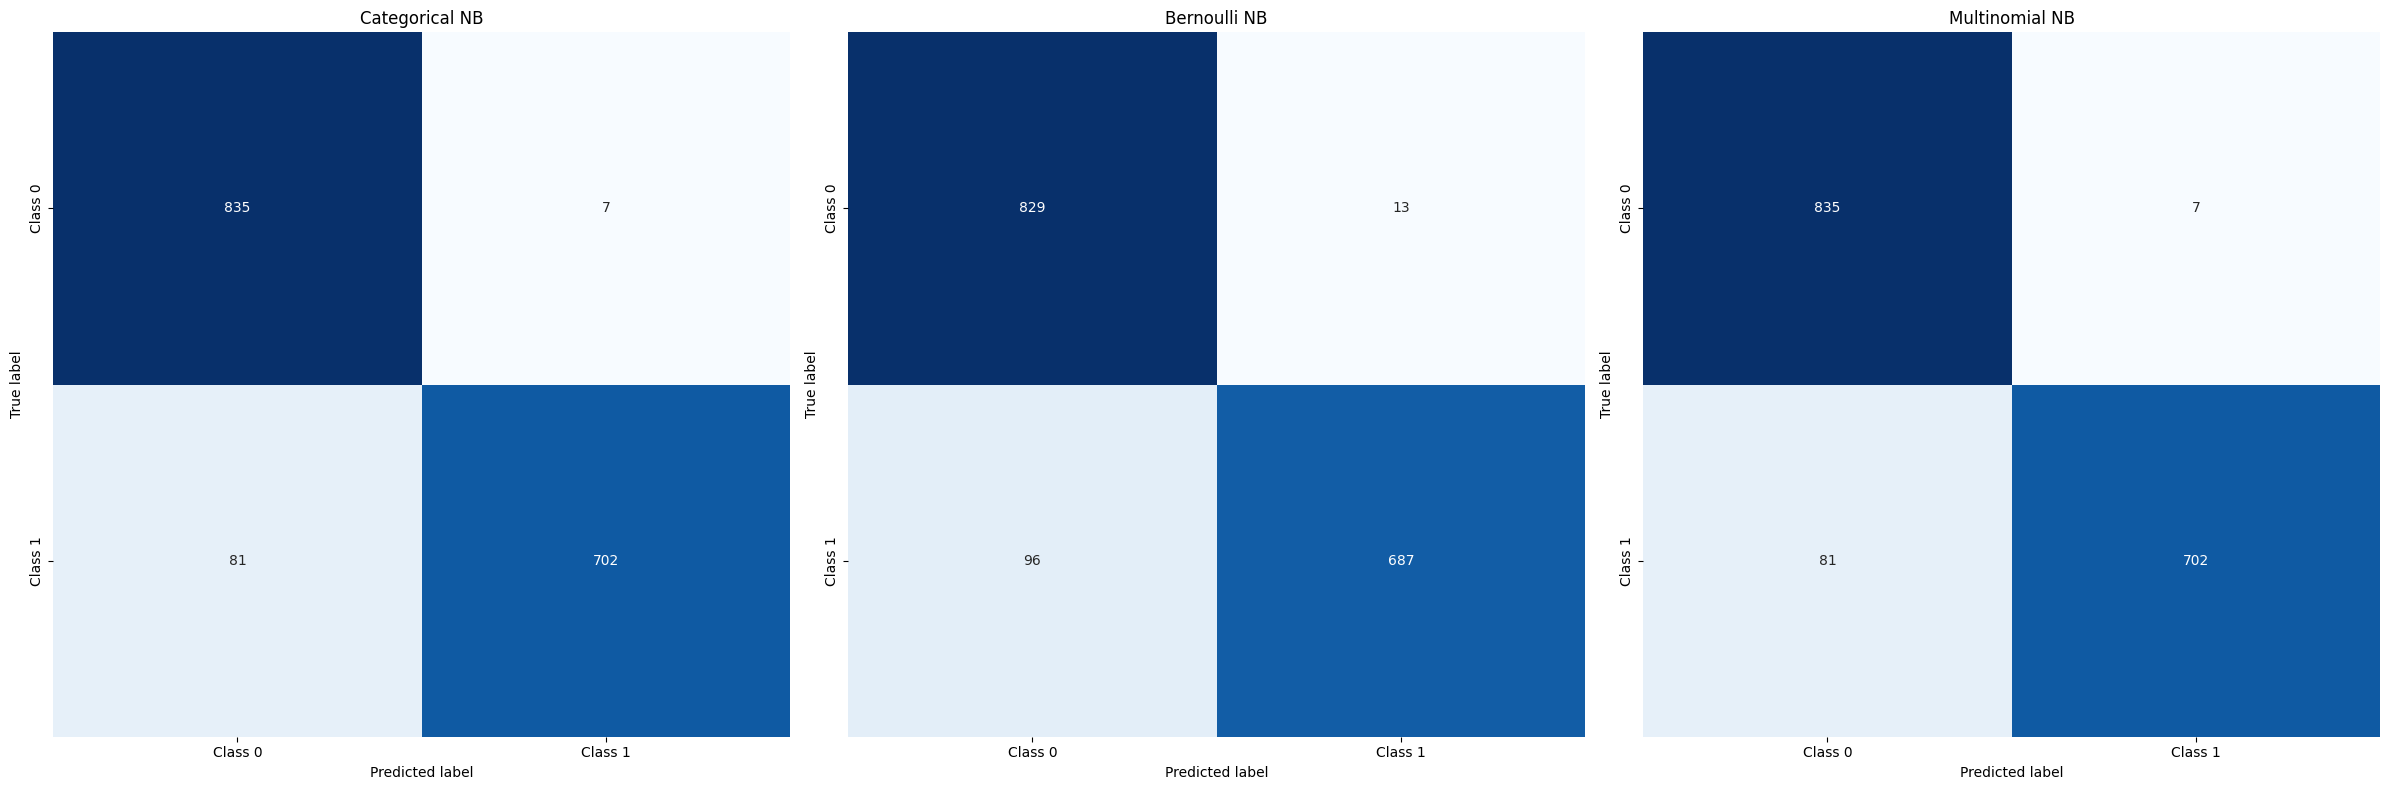

In [38]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
from sklearn.metrics import confusion_matrix

cmCNB = confusion_matrix(y_test, y_pred_NB)
cmBNB = confusion_matrix(y_test, y_pred_BNB)
cmMNB = confusion_matrix(y_test, y_pred_MNB)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8))

for ax, cm, title in zip(
    axes,
    [cmCNB, cmBNB, cmMNB],
    ["Categorical NB", "Bernoulli NB", "Multinomial NB"]
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"]
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

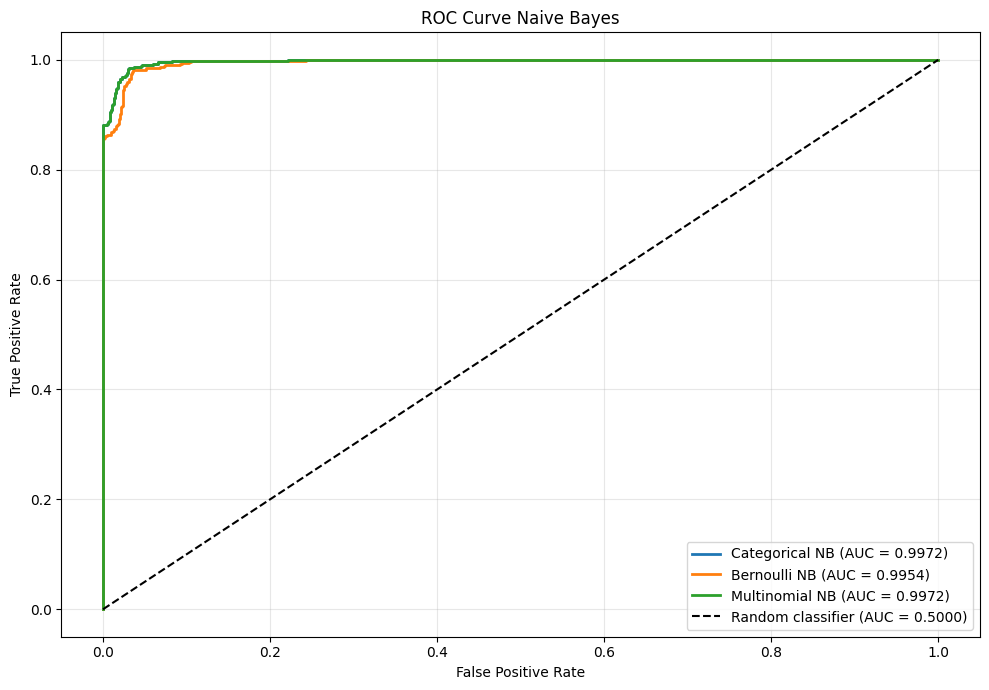

In [39]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
from sklearn.metrics import auc, roc_curve

model_probabilities = {
    "Categorical NB": Naive_Bayes.predict_proba(X_test_encoded)[:, 1],
    "Bernoulli NB": BNaive_Bayes.predict_proba(X_test_OHEencoded)[:, 1],
    "Multinomial NB": MNaive_Bayes.predict_proba(X_test_OHEencoded)[:, 1]
}

plt.figure(figsize=(10, 7))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    model_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {model_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random classifier (AUC = 0.5000)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Naive Bayes")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

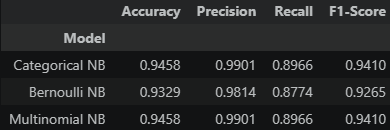

Data yang dipakai merupakan data balanced sehingga tidak diperlukan handling seperti data augmentasi untuk menyeimbangkan data, selisih pada class data sangat minim sehingga dapat diabaikan

Berdasarkan tabel peforma diatas dapat dilihat bahwa Categorical Naive Bayes dan Multinomial memiliki peforma yang lebih baik daripada Bernouli, Categorical Naive Bayes memiliki peforma yang bagus karena data mentah merupakan data dengan fitur categorical, untuk Multinomial berarti representasi count lebih baik dari pada biner di bernouli naive bayes. Namun selisih dari ketiga data tersebut sangat minim.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulan:

Menerapkan jenis algoritma naive bayes sesuai dengan jenis data yang disarankan memungkinkan kita untuk dapat model naive bayes terbaik. Namun, tidak menutup kemungkinan bahwa model naive bayes yang lain juga sama bagusnya dengan jenis naive bayes yang cocok tersebut.

Saran:

Bisa dilakukan eksperimen dengan model klasifikasi lain seperti logistik regression dll untuk perbandingan peforma yang lebih mendalam
